# Análisis exploratorio de datos: TrashNet

Este notebook analiza la descarga local de TrashNet desde Kaggle. Informa sobre la estructura del conjunto de datos, sus clases, las características de las imágenes y el número de imágenes disponibles en el subconjunto de origen.

Los datos descargados contienen un único subconjunto de origen (`dataset-resized`) y no incluyen carpetas predefinidas para entrenamiento, validación o prueba.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

DATASET_ROOT = Path(r"C:\Users\User\.cache\kagglehub\datasets\feyzazkefe\trashnet\versions\1\dataset-resized")
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp", ".tif", ".tiff"}
EXPECTED_CLASSES = {"cardboard", "glass", "metal", "paper", "plastic", "trash"}

if not DATASET_ROOT.is_dir():
    raise FileNotFoundError(f"Dataset root not found: {DATASET_ROOT}")

# Cada carpeta directamente bajo la raíz representa una clase del conjunto de datos.
class_dirs = sorted(path for path in DATASET_ROOT.iterdir() if path.is_dir())
class_names = [path.name for path in class_dirs]
unexpected_classes = set(class_names) - EXPECTED_CLASSES
missing_expected_classes = EXPECTED_CLASSES - set(class_names)
print(f"Dataset root: {DATASET_ROOT}")
print(f"Detected class directories ({len(class_names)}): {class_names}")
if unexpected_classes or missing_expected_classes:
    print(f"Unexpected classes: {sorted(unexpected_classes)}")
    print(f"Missing expected classes: {sorted(missing_expected_classes)}")

Dataset root: C:\Users\User\.cache\kagglehub\datasets\feyzazkefe\trashnet\versions\1\dataset-resized
Detected class directories (6): ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## 1. Estructura del conjunto de datos y subconjunto de origen

Los nombres de las carpetas se utilizan como etiquetas de clase. Como no existen carpetas anidadas para dividir los datos, todas las imágenes descubiertas pertenecen al único subconjunto de origen descargado.

In [ ]:
all_files = [path for path in DATASET_ROOT.rglob("*") if path.is_file()]
# Se filtran por extensión para separar imágenes de archivos auxiliares.
image_paths = sorted(path for path in all_files if path.suffix.lower() in IMAGE_EXTENSIONS)
non_image_files = sorted(path for path in all_files if path.suffix.lower() not in IMAGE_EXTENSIONS)

structure_table = pd.DataFrame({
    "class": class_names,
    "image_files": [sum(path.parent == class_dir and path.suffix.lower() in IMAGE_EXTENSIONS for path in all_files) for class_dir in class_dirs],
})

print(f"Number of classes: {len(class_names)}")
print(f"Total image files: {len(image_paths):,}")
print(f"Non-image files: {len(non_image_files):,}")
print("Source subset: dataset-resized (no predefined train/validation/test subsets)")
display(structure_table)
if non_image_files:
    print("Non-image files found:")
    display(pd.DataFrame({"path": [str(path.relative_to(DATASET_ROOT)) for path in non_image_files]}))

Number of classes: 6
Total image files: 2,527
Non-image files: 0
Source subset: dataset-resized (no predefined train/validation/test subsets)


,class,image_files
0,cardboard,403
1,glass,501
2,metal,410
3,paper,594
4,plastic,482
5,trash,137


## 2. Metadatos de las imágenes

Cada imagen se inspecciona para obtener el tamaño del archivo, las dimensiones, el modo de color, los canales, la proporción de aspecto y su legibilidad. Los archivos ilegibles permanecen en la tabla de metadatos.

In [ ]:
def channel_count(mode):
    # Algunos modos de Pillow no representan un número simple de canales.
    return len(mode) if mode in {"1", "L", "LA", "P", "RGB", "RGBA", "CMYK", "YCbCr", "I", "F"} else np.nan

metadata_rows = []
for path in image_paths:
    row = {
        "class": path.parent.name,
        "filename": path.name,
        "relative_path": str(path.relative_to(DATASET_ROOT)),
        "extension": path.suffix.lower(),
        "file_size_kb": path.stat().st_size / 1024,
        "width": np.nan,
        "height": np.nan,
        "color_mode": None,
        "channels": np.nan,
        "aspect_ratio": np.nan,
        "readable": False,
        "error": None,
    }
    try:
        # Se conserva la fila aunque Pillow no pueda abrir la imagen.
        with Image.open(path) as image:
            width, height = image.size
            row.update({
                "width": width,
                "height": height,
                "color_mode": image.mode,
                "channels": channel_count(image.mode),
                "aspect_ratio": width / height if height else np.nan,
                "readable": True,
            })
    except Exception as error:
        row["error"] = repr(error)
    metadata_rows.append(row)

metadata = pd.DataFrame(metadata_rows)
readable = metadata[metadata["readable"]].copy()
unreadable = metadata[~metadata["readable"]].copy()
print(f"Readable images: {len(readable):,}")
print(f"Unreadable images: {len(unreadable):,}")
display(metadata.head())
if unreadable.empty:
    print("No unreadable image files were detected.")
else:
    display(unreadable[["relative_path", "error"]])

Readable images: 2,527
Unreadable images: 0


,class,filename,relative_path,extension,file_size_kb,width,height,color_mode,channels,aspect_ratio,readable,error
0,cardboard,cardboard1.jpg,cardboard\cardboard1.jpg,.jpg,16.926758,512,384,RGB,3,1.333333,True,None
1,cardboard,cardboard10.jpg,cardboard\cardboard10.jpg,.jpg,21.174805,512,384,RGB,3,1.333333,True,None
2,cardboard,cardboard100.jpg,cardboard\cardboard100.jpg,.jpg,14.535156,512,384,RGB,3,1.333333,True,None
3,cardboard,cardboard101.jpg,cardboard\cardboard101.jpg,.jpg,13.954102,512,384,RGB,3,1.333333,True,None
4,cardboard,cardboard102.jpg,cardboard\cardboard102.jpg,.jpg,17.592773,512,384,RGB,3,1.333333,True,None


No unreadable image files were detected.


## 3. Clases y cantidad de imágenes

La tabla de clases se ordena por cantidad de imágenes.

,images,readable_images,percentage
class,,,
paper,594,594,23.51%
glass,501,501,19.83%
plastic,482,482,19.07%
metal,410,410,16.22%
cardboard,403,403,15.95%
trash,137,137,5.42%


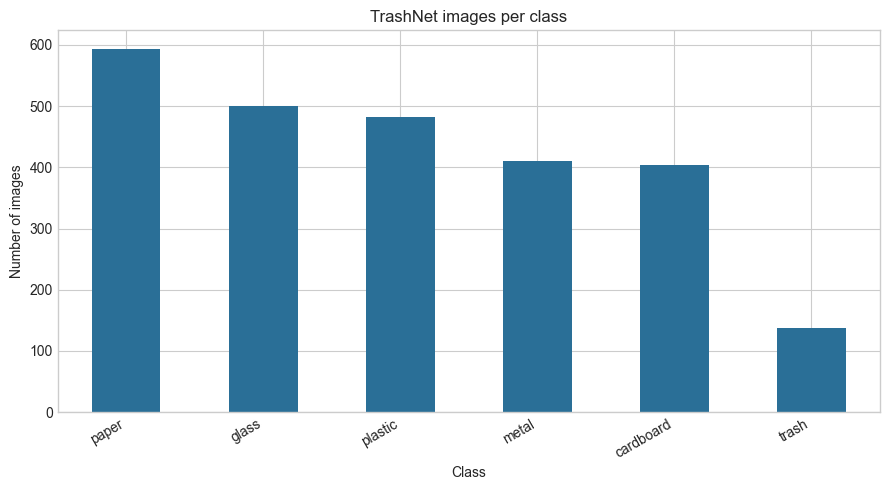

In [ ]:
class_counts = (
    metadata.groupby("class", sort=False)
    .agg(images=("relative_path", "count"), readable_images=("readable", "sum"))
    .sort_values("images", ascending=False)
)
class_counts["percentage"] = 100 * class_counts["images"] / len(metadata)
display(class_counts.style.format({"percentage": "{:.2f}%"}))

ax = class_counts["images"].plot(kind="bar", figsize=(9, 5), color="#2a6f97")
ax.set_title("Imágenes de TrashNet por clase")
ax.set_xlabel("Clase")
ax.set_ylabel("Número de imágenes")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 4. Cuatro intervalos de igual amplitud para las dimensiones y la proporción de aspecto

La siguiente función crea exactamente cuatro intervalos de igual amplitud usando el mínimo y el máximo observados. No son cuantiles: sus amplitudes numéricas son iguales, pero la cantidad de imágenes en cada intervalo puede variar.

In [ ]:
def equal_width_bins(series, n_bins=4, decimals=2):
    values = pd.to_numeric(series, errors="coerce").dropna()

    if values.empty:
        raise ValueError("La serie no contiene valores numéricos.")

    minimum = float(values.min())
    maximum = float(values.max())

    if minimum == maximum:
        # Se amplía un valor constante para poder crear cuatro intervalos válidos.
        edges = np.linspace(
            minimum - 0.5,
            maximum + 0.5,
            n_bins + 1
        )
    else:
        edges = np.linspace(minimum, maximum, n_bins + 1)

    labels = [
        f"{edges[index]:.{decimals}f} a "
        f"{edges[index + 1]:.{decimals}f}"
        for index in range(n_bins)
    ]

    # Primero se asignan índices numéricos para evitar errores de pd.cut con etiquetas.
    bin_indexes = pd.cut(
        values,
        bins=edges,
        labels=False,
        include_lowest=True
    )

    categories = bin_indexes.map(
        dict(enumerate(labels))
    )

    return categories, edges, labels

In [ ]:
def cluster_summary(data, column, decimals=2):
    categories, edges, labels = equal_width_bins(data[column], decimals=decimals)
    summary = categories.value_counts(sort=False).rename("images").to_frame()
    summary["percentage"] = 100 * summary["images"] / len(data)
    summary.index.name = f"{column}_cluster"
    return summary, edges, labels

width_summary, width_edges, width_labels = cluster_summary(readable, "width", decimals=0)
height_summary, height_edges, height_labels = cluster_summary(readable, "height", decimals=0)
aspect_summary, aspect_edges, aspect_labels = cluster_summary(readable, "aspect_ratio", decimals=2)

print("Intervalos de anchura")
display(width_summary.style.format({"percentage": "{:.2f}%"}))
print("Intervalos de altura")
display(height_summary.style.format({"percentage": "{:.2f}%"}))
print("Intervalos de proporción de aspecto")
display(aspect_summary.style.format({"percentage": "{:.2f}%"}))
print(f"Rango de anchura: {width_edges[0]:.0f} a {width_edges[-1]:.0f}")
print(f"Rango de altura: {height_edges[0]:.0f} a {height_edges[-1]:.0f}")
print(f"Rango de proporción de aspecto: {aspect_edges[0]:.2f} a {aspect_edges[-1]:.2f}")

Width clusters


,images,percentage
width_cluster,,
512 to 512,2527,100.00%


Height clusters


,images,percentage
height_cluster,,
384 to 384,2527,100.00%


Aspect-ratio clusters


,images,percentage
aspect_ratio_cluster,,
1.08 to 1.33,2527,100.00%


Width range: 512 to 512
Height range: 384 to 384
Aspect-ratio range: 0.83 to 1.83


height,384 to 384,384 to 384,384 to 384,384 to 384
width,,,,
512 to 512,2527,2527,2527,2527
512 to 512,2527,2527,2527,2527
512 to 512,2527,2527,2527,2527
512 to 512,2527,2527,2527,2527


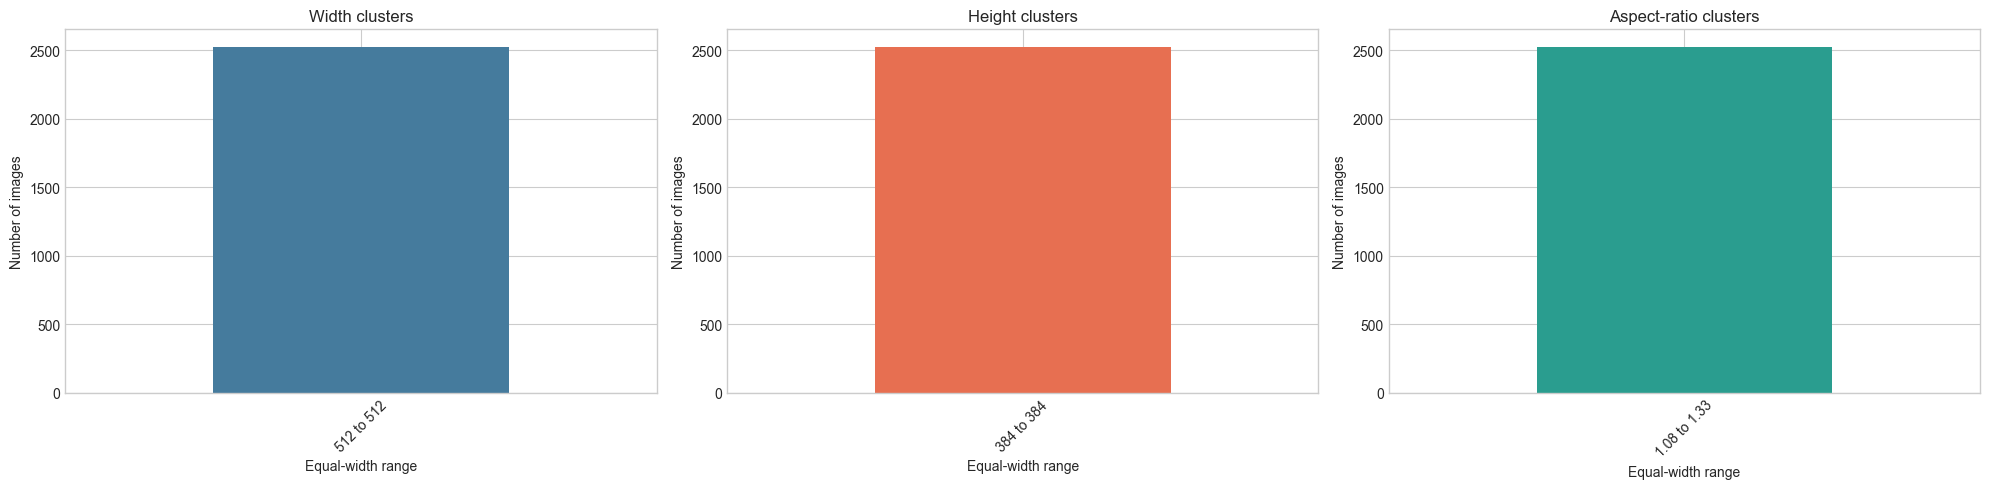

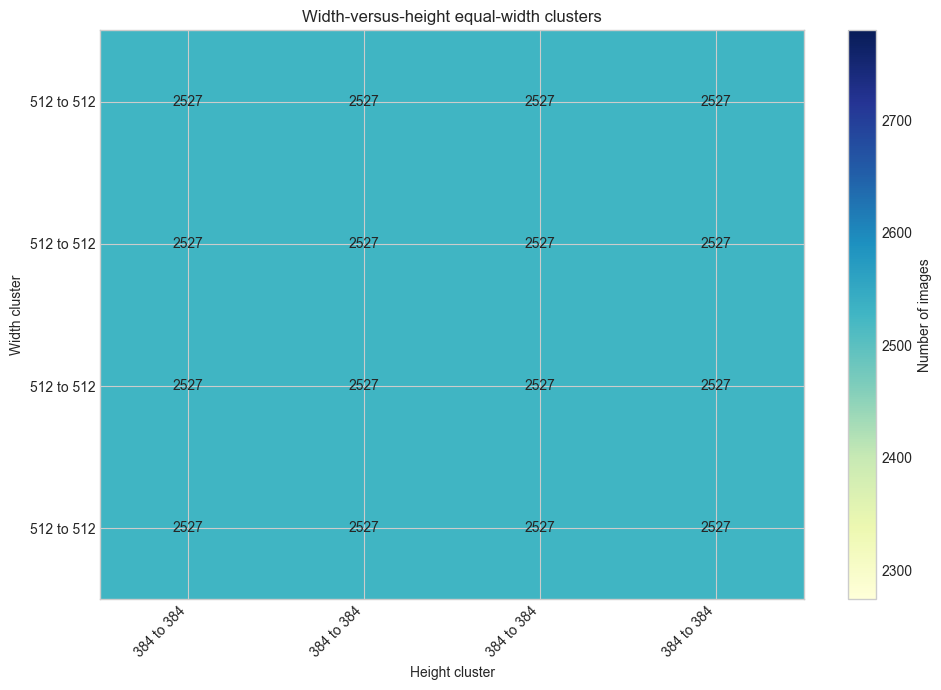

In [ ]:
width_cluster, _, _ = equal_width_bins(readable["width"], decimals=0)
height_cluster, _, _ = equal_width_bins(readable["height"], decimals=0)
# La tabla cruzada muestra cuántas imágenes caen en cada combinación de intervalos.
dimension_clusters = pd.crosstab(width_cluster, height_cluster, dropna=False)
dimension_clusters = dimension_clusters.reindex(index=width_labels, columns=height_labels, fill_value=0)
display(dimension_clusters)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
width_summary["images"].plot(kind="bar", ax=axes[0], color="#457b9d", title="Intervalos de anchura")
height_summary["images"].plot(kind="bar", ax=axes[1], color="#e76f51", title="Intervalos de altura")
aspect_summary["images"].plot(kind="bar", ax=axes[2], color="#2a9d8f", title="Intervalos de proporción de aspecto")
for axis in axes:
    axis.set_xlabel("Rango de igual amplitud")
    axis.set_ylabel("Número de imágenes")
    axis.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
plt.imshow(dimension_clusters, cmap="YlGnBu", aspect="auto")
plt.colorbar(label="Número de imágenes")
plt.xticks(range(len(height_labels)), height_labels, rotation=45, ha="right")
plt.yticks(range(len(width_labels)), width_labels)
plt.xlabel("Intervalo de altura")
plt.ylabel("Intervalo de anchura")
plt.title("Intervalos de igual amplitud de anchura frente a altura")
for row_index in range(dimension_clusters.shape[0]):
    for column_index in range(dimension_clusters.shape[1]):
        value = dimension_clusters.iloc[row_index, column_index]
        plt.text(column_index, row_index, value, ha="center", va="center")
plt.tight_layout()
plt.show()

## 5. Modos de color y cantidad de canales

El modo de color es una variable categórica. La tabla conserva los nombres de los modos observados y su cantidad de canales, en lugar de tratarlos como valores continuos.

,color_mode,channels,images,percentage
0,RGB,3,2527,100.00%


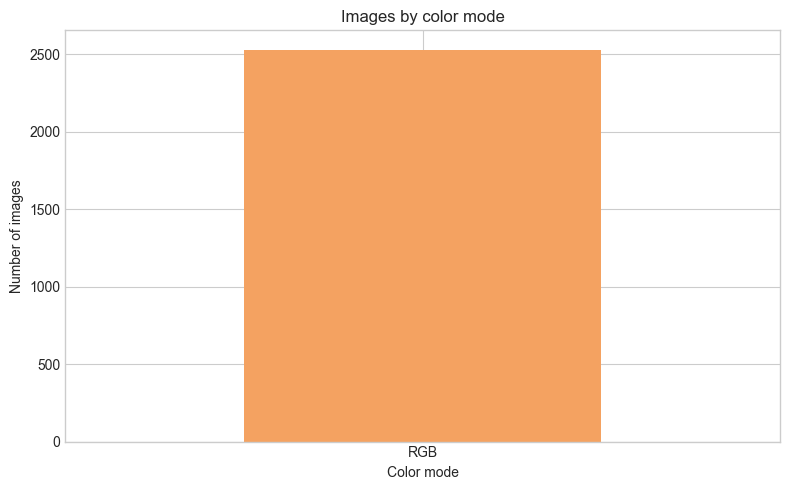

In [ ]:
mode_summary = (
    readable.groupby(["color_mode", "channels"], dropna=False)
    .size().rename("images").reset_index()
    .sort_values("images", ascending=False)
)
mode_summary["percentage"] = 100 * mode_summary["images"] / len(readable)
display(mode_summary.style.format({"percentage": "{:.2f}%"}))

ax = mode_summary.set_index("color_mode")["images"].plot(kind="bar", figsize=(8, 5), color="#f4a261")
ax.set_title("Imágenes por modo de color")
ax.set_xlabel("Modo de color")
ax.set_ylabel("Número de imágenes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Resúmenes de archivos e imágenes representativas

,images
extension,
.jpg,2527


,file_size_kb
count,2527.000000
mean,16.726542
std,7.420650
min,5.472656
25%,11.628418
50%,15.024414
75%,19.827148
max,56.511719


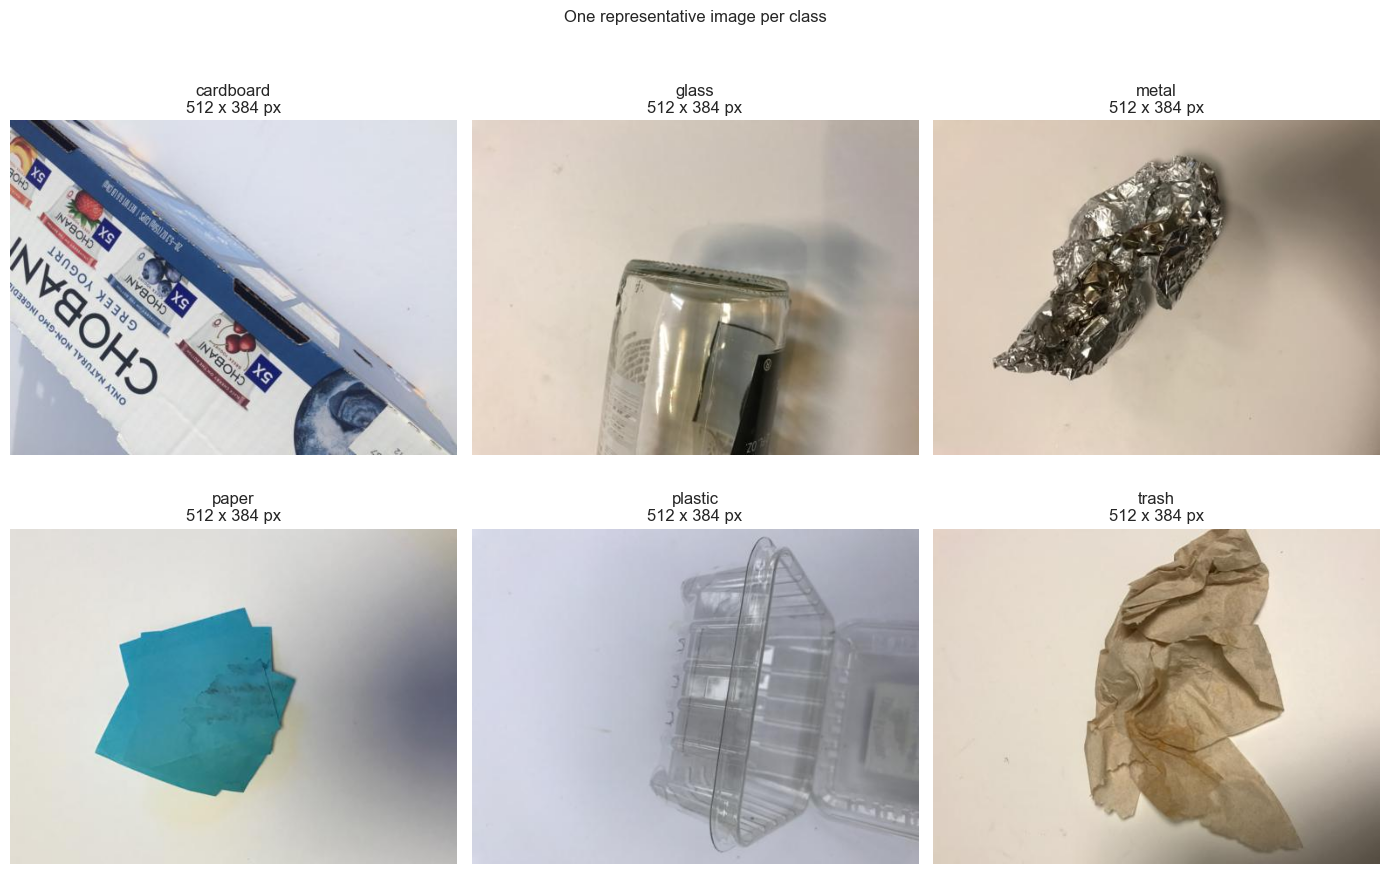

In [ ]:
extension_summary = readable["extension"].value_counts().rename_axis("extension").to_frame("images")
file_size_summary = readable["file_size_kb"].describe().to_frame("file_size_kb")
display(extension_summary)
display(file_size_summary)

# Se toma una imagen reproducible por clase y se conserva la columna "class".
sample_per_class = readable.groupby(
    "class", group_keys=False
).sample(n=1, random_state=42)
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for axis, (_, row) in zip(axes.flat, sample_per_class.iterrows()):
    image = Image.open(DATASET_ROOT / row["relative_path"]).convert("RGB")
    axis.imshow(image)
    axis.set_title(f"{row['class']}\n{row['width']} x {row['height']} px")
    axis.axis("off")
for axis in axes.flat[len(sample_per_class):]:
    axis.axis("off")
plt.suptitle("Una imagen representativa por clase", y=1.02)
plt.tight_layout()
plt.show()

## 7. Conclusiones y limitaciones

- El subconjunto de origen es la carpeta completa `dataset-resized`; no se incluye una división predefinida en entrenamiento, validación y prueba.
- Todas las imagenes son de 512x384 pixeles. Cualquier data augmentation externo, debera normalizarse inicialmente a ese tamaño.
- Todas las imagenes estan compuestas por los tres canales RGB.
- La clase "Trash" que equivaldria a la clase "No reciclable" contiene practicamente solo 100 imagenes. Data augmentation sera necesario o una designacion programatica a todo aquello que no sea clasificado como alguna de las 6 clases del dataset.